# **Importing required Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, mannwhitneyu

import os
import warnings
warnings.filterwarnings("ignore")

# Step 1: Data Understanding

### **load the dataset**

In [3]:
df = pd.read_csv("data/ids.csv")
df

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,53,62171,2,2,78,164,39,39,39.00,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
1,1,2710,48,2,0,4,0,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
2,2,443,4792909,5,1,135,46,46,6,27.00,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
3,3,80,115596470,75,82,342,118155,342,0,4.56,...,32,22092.63636,22835.59127,90944,14999,10000000.0,2701.650839,10000000,9997164,BENIGN
4,4,2910,14,2,2,4,12,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,488110,53,238,2,2,86,228,43,43,43.00,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
488111,488111,8899,3,2,0,4,0,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
488112,488112,53,250,2,2,82,206,41,41,41.00,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
488113,488113,53,70581019,2,2,117,231,66,51,58.50,...,32,41306.00000,0.00000,41306,41306,70300000.0,0.000000,70300000,70300000,BENIGN


## **1.2 Display First and Last 5 records**

In [4]:
df.head()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,53,62171,2,2,78,164,39,39,39.00,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
1,1,2710,48,2,0,4,0,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
2,2,443,4792909,5,1,135,46,46,6,27.00,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
3,3,80,115596470,75,82,342,118155,342,0,4.56,...,32,22092.63636,22835.59127,90944,14999,10000000.0,2701.650839,10000000,9997164,BENIGN
4,4,2910,14,2,2,4,12,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN


In [5]:
df.size

39049200

In [6]:
df.tail()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488110,488110,53,238,2,2,86,228,43,43,43.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
488111,488111,8899,3,2,0,4,0,2,2,2.0,...,24,0.0,0.0,0,0,0.0,0.0,0,0,Infiltration
488112,488112,53,250,2,2,82,206,41,41,41.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
488113,488113,53,70581019,2,2,117,231,66,51,58.5,...,32,41306.0,0.0,41306,41306,70300000.0,0.0,70300000,70300000,BENIGN
488114,488114,5679,121,2,2,4,12,2,2,2.0,...,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## **1.3 Check Shape**

In [7]:
print("shape:", df.shape)

shape: (488115, 80)


## **1.4 Check Columns**

In [8]:
print("Columns:", df.columns)

Columns: Index(['Unnamed: 0', 'Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Coun

## **1.5 Check Data Types**

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 488115 entries, 0 to 488114
Data columns (total 80 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   488115 non-null  int64  
 1   Destination Port             488115 non-null  int64  
 2   Flow Duration                488115 non-null  int64  
 3   Total Fwd Packets            488115 non-null  int64  
 4   Total Backward Packets       488115 non-null  int64  
 5   Total Length of Fwd Packets  488115 non-null  int64  
 6   Total Length of Bwd Packets  488115 non-null  int64  
 7   Fwd Packet Length Max        488115 non-null  int64  
 8   Fwd Packet Length Min        488115 non-null  int64  
 9   Fwd Packet Length Mean       488115 non-null  float64
 10  Fwd Packet Length Std        488115 non-null  float64
 11  Bwd Packet Length Max        488115 non-null  int64  
 12  Bwd Packet Length Min        488115 non-null  int64  
 13  Bwd Packet

## **Summary Statistics**

In [10]:
df.describe()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,488115.00000,488115.000000,4.881150e+05,488115.000000,488115.000000,4.881150e+05,4.881150e+05,488115.000000,488115.000000,488115.000000,...,488115.000000,488115.000000,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05
mean,244057.00000,8216.354384,8.942263e+06,6.206931,6.185579,5.581399e+02,6.222017e+03,140.936187,17.142253,41.737297,...,3.436965,25.697270,6.169126e+04,4.144031e+04,1.325706e+05,3.851845e+04,2.606171e+06,1.184684e+05,2.695488e+06,2.483101e+06
std,140906.80766,17541.650108,2.748091e+07,69.852691,99.359121,2.738195e+04,1.788109e+05,438.404840,31.486744,119.415855,...,50.611058,5.851988,5.330001e+05,3.753807e+05,9.292890e+05,4.588439e+05,1.067120e+07,1.614595e+06,1.096955e+07,1.050593e+07
min,0.00000,0.000000,-2.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,122028.50000,53.000000,5.900000e+01,2.000000,1.000000,4.000000e+00,0.000000e+00,2.000000,0.000000,2.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,244057.00000,443.000000,3.100000e+02,2.000000,2.000000,4.900000e+01,7.200000e+01,32.000000,2.000000,29.000000,...,1.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,366085.50000,3221.000000,1.002090e+05,3.000000,2.000000,9.500000e+01,2.460000e+02,51.000000,35.000000,46.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,488114.00000,65533.000000,1.199999e+08,22673.000000,44553.000000,1.290000e+07,6.360000e+07,23360.000000,2065.000000,4317.097561,...,9130.000000,60.000000,6.520000e+07,3.810000e+07,7.910000e+07,6.520000e+07,1.200000e+08,7.530000e+07,1.200000e+08,1.200000e+08


## **Step 2: Data Preparation**

### Remove unnecessary columns

In [11]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,62171,2,2,78,164,39,39,39.00,0.000000,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
1,2710,48,2,0,4,0,2,2,2.00,0.000000,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
2,443,4792909,5,1,135,46,46,6,27.00,20.124612,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
3,80,115596470,75,82,342,118155,342,0,4.56,39.490758,...,32,22092.63636,22835.59127,90944,14999,10000000.0,2701.650839,10000000,9997164,BENIGN
4,2910,14,2,2,4,12,2,2,2.00,0.000000,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,53,238,2,2,86,228,43,43,43.00,0.000000,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
488111,8899,3,2,0,4,0,2,2,2.00,0.000000,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
488112,53,250,2,2,82,206,41,41,41.00,0.000000,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
488113,53,70581019,2,2,117,231,66,51,58.50,10.606602,...,32,41306.00000,0.00000,41306,41306,70300000.0,0.000000,70300000,70300000,BENIGN


In [12]:
df.tail(50)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488065,53,70591,2,2,66,194,33,33,33.000000,0.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration
488066,443,5572560,8,6,386,5205,205,0,48.250000,75.952523,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488067,3013,49,2,0,4,0,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488068,53,122130,2,2,80,272,40,40,40.000000,0.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488069,53,98106274,2,2,114,211,58,56,57.000000,1.414214,...,20,30943.00000,0.00000,30943,30943,9.800000e+07,0.00000,98000000,98000000,Infiltration
488070,53,506,1,1,53,113,53,53,53.000000,0.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488071,53,3957631,2,2,120,260,79,41,60.000000,26.870058,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488072,9102,2,2,0,4,0,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488073,2135,111,2,2,4,12,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488074,1048,49,2,0,4,0,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration


### **Creating New DataFrame (selected columns)**

In [13]:
# Required Columns
columns = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets',
    'Total Backward Packets', 'Total Length of Fwd Packets',
    'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 
     'Bwd Packet Length Mean', 'Flow Bytes/s',  'Flow Packets/s', 
    'Packet Length Mean','Packet Length Std','Average Packet Size', 
    'Active Mean', 'Idle Mean', 'Label']


#create new dataframe with selected columns
data = df[columns]
data




,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,BENIGN
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,BENIGN
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,BENIGN
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,53,238,2,2,86,228,43.00,114.000000,1.319328e+06,16806.722690,71.400000,38.888302,89.250000,0.00000,0.0,BENIGN
488111,8899,3,2,0,4,0,2.00,0.000000,1.333333e+06,666666.666700,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
488112,53,250,2,2,82,206,41.00,103.000000,1.152000e+06,16000.000000,65.800000,33.958799,82.250000,0.00000,0.0,BENIGN
488113,53,70581019,2,2,117,231,58.50,115.500000,4.930504e+00,0.056672,82.800000,30.817203,103.500000,41306.00000,70300000.0,BENIGN


**Checking Missing Values**

In [14]:
data.isnull().sum()

Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Mean          0
Bwd Packet Length Mean          0
Flow Bytes/s                   36
Flow Packets/s                  0
Packet Length Mean              0
Packet Length Std               0
Average Packet Size             0
Active Mean                     0
Idle Mean                       0
Label                           0
dtype: int64

**Remove rows with missing values**

In [15]:
data = data.dropna()
data

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,BENIGN
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,BENIGN
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,BENIGN
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,53,238,2,2,86,228,43.00,114.000000,1.319328e+06,16806.722690,71.400000,38.888302,89.250000,0.00000,0.0,BENIGN
488111,8899,3,2,0,4,0,2.00,0.000000,1.333333e+06,666666.666700,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
488112,53,250,2,2,82,206,41.00,103.000000,1.152000e+06,16000.000000,65.800000,33.958799,82.250000,0.00000,0.0,BENIGN
488113,53,70581019,2,2,117,231,58.50,115.500000,4.930504e+00,0.056672,82.800000,30.817203,103.500000,41306.00000,70300000.0,BENIGN


**Verify Missing values removed**

In [16]:
print("Missing values after cleaning:")
print(data.isnull().sum())

Missing values after cleaning:
Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Mean         0
Bwd Packet Length Mean         0
Flow Bytes/s                   0
Flow Packets/s                 0
Packet Length Mean             0
Packet Length Std              0
Average Packet Size            0
Active Mean                    0
Idle Mean                      0
Label                          0
dtype: int64


**Check Duplicates**

In [17]:
print("Duplicate row after cleaning:", data.duplicated().sum())

Duplicate row after cleaning: 139389


**Total number of columns & names of columns**

In [18]:
#total number of columns
print("Total number of columns:", data.shape[1])

print("Columns name:", data.columns)

Total number of columns: 16
Columns name: Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
       'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
       'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
       'Active Mean', 'Idle Mean', 'Label'],
      dtype='str')


**Rename Data values**

In [19]:
#rename values in label columns
data['Label'] = data['Label'].replace({
    'BENIGN': 'Normal Traffic',
    'Infiltration': 'Attack'
})

#verify updated labels
data['Label'].value_counts()

Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64

### **Data Anlaysis**


**Statistical Measures (2 Variables)**

In [20]:
# Select two columns
selected_cols = ["Flow Duration", "Packet Length Mean"]

# Create summary statictics 

#apply aggregation
stats = df[selected_cols].agg(['sum', 'mean', 'std', 'skew', 'kurt',])

#display result
print("Statistical Analysis:")
print(stats)

Statistical Analysis:
      Flow Duration  Packet Length Mean
sum    4.364853e+12        4.175763e+07
mean   8.942263e+06        8.554875e+01
std    2.748091e+07        1.738676e+02
skew   3.251026e+00        4.935916e+00
kurt   9.247816e+00        3.461266e+01


**Correlation Analysis**

In [21]:
numeric_data = data.select_dtypes(include=["number"])
corr_matrix = numeric_data.corr(numeric_only=True)

top5 = corr_matrix["Flow Duration"].sort_values(ascending=False)

print("\nTop 5 Correlation Features:")
print(top5.head(5))


Top 5 Correlation Features:
Flow Duration             1.000000
Idle Mean                 0.653138
Packet Length Std         0.465984
Bwd Packet Length Mean    0.351037
Packet Length Mean        0.324827
Name: Flow Duration, dtype: float64


# Step 4: Data Exploration

## **Bar Chart (Label Distribution)**

The bar chart shows that the dataset is imbalanced, as one label `(Normal Traffic or Attack)` has significantly higher frequency than the other, meaning the dependent variable is not evenly distributed

In [22]:
label_count = data["Label"].value_counts()
label_count

Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64

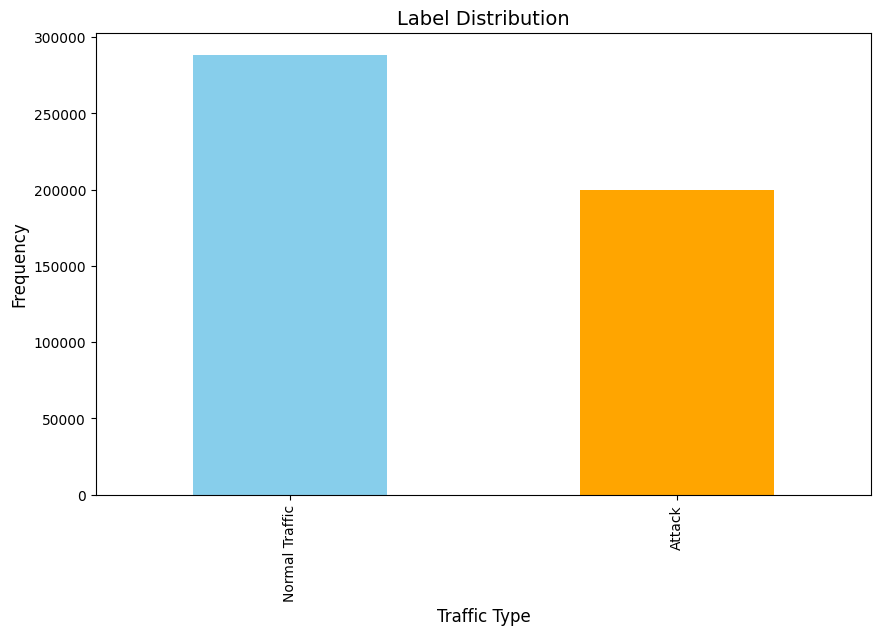

In [23]:
plt.figure(figsize=(10,6))

label_count.plot(kind="bar", color=["skyblue", "orange"])

plt.title("Label Distribution", fontsize=14)
plt.xlabel("Traffic Type", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

## **Pie Chart**

### **Average Comparision (Grouby)**

**Flow Duration and Packet Length Mean**

The group-wise mean shows which traffic type `(Normal or Attack)` dominates in terms of Flow Duration and Packet Length behavior. Sorting and idmax() helps to identify the dominant category efficiency

In [24]:
# Group data by Label

grouped = data.groupby("Label")

# Mean Calculate
flow_mean = grouped["Flow Duration"].mean()
packet_mean = grouped["Packet Length Mean"].mean()

# Display results clearly
print("Flow Duration Mean:", flow_mean)
print("\nPacket Length Mean:", packet_mean)

Flow Duration Mean: Label
Attack            8.909046e+06
Normal Traffic    8.966348e+06
Name: Flow Duration, dtype: float64

Packet Length Mean: Label
Attack            85.573255
Normal Traffic    85.542480
Name: Packet Length Mean, dtype: float64
